## Ejercicio Regresión Polinómica 2

Usando los ejemplos hechos en clase debes resolver el problema que se plantea a continuación.

Usando los datos de casos confirmados de COVID-19 en el mundo frente a los días pasados desde que empezó la pandemia, haz el mejor predictor posible.



In [1]:
import pandas as pd
covid = pd.read_csv('time_series_covid19_confirmed_global.csv')
covid.head()

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,2/19/22,2/20/22,2/21/22,2/22/22,2/23/22,2/24/22,2/25/22,2/26/22,2/27/22,2/28/22
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,171931,172205,172441,172716,172901,173047,173084,173146,173395,173659
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,269904,270164,270370,270455,270734,270947,271141,271141,271527,271563
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,263936,264054,264201,264365,264488,264603,264706,264778,264855,264936
3,NaN,Andorra,42.50630,1.521800,0,0,0,0,0,0,...,37589,37589,37589,37820,37901,37958,37999,37999,37999,37999
4,NaN,Angola,-11.20270,17.873900,0,0,0,0,0,0,...,98617,98638,98658,98671,98698,98701,98701,98701,98701,98741


In [2]:
#Empezamos preparando los datos. Vamos a generar un dataframe con los días desde el comienzo de la 
#pandemia y el número de casos confirmados.
#dias_desde_inicio #numero_casos(totales,suma de los de todos los paises)
#0                   5
#1                   120
#2                   300
#3   
#4
#5

covid.drop(['Province/State','Country/Region','Lat','Long'],axis=1,inplace=True)
covid.head()


,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,1/28/20,1/29/20,1/30/20,1/31/20,...,2/19/22,2/20/22,2/21/22,2/22/22,2/23/22,2/24/22,2/25/22,2/26/22,2/27/22,2/28/22
0,0,0,0,0,0,0,0,0,0,0,...,171931,172205,172441,172716,172901,173047,173084,173146,173395,173659
1,0,0,0,0,0,0,0,0,0,0,...,269904,270164,270370,270455,270734,270947,271141,271141,271527,271563
2,0,0,0,0,0,0,0,0,0,0,...,263936,264054,264201,264365,264488,264603,264706,264778,264855,264936
3,0,0,0,0,0,0,0,0,0,0,...,37589,37589,37589,37820,37901,37958,37999,37999,37999,37999
4,0,0,0,0,0,0,0,0,0,0,...,98617,98638,98658,98671,98698,98701,98701,98701,98701,98741


In [3]:
dias = covid.columns
dias_inicio = []
casos = []
#marketing['Dt_Customer'] = pd.to_datetime(marketing['Dt_Customer'],dayfirst=True)
for dia in dias:
    #print(dia)
    dias_inicio.append((pd.to_datetime(dia)-pd.to_datetime(dias[0])).days)
    casos.append(sum(covid[dia]))

In [ ]:
print(dias_inicio[0:20])
print(casos[0:20])
print(len(dias_inicio))
print(len(casos))
covid_dias = pd.DataFrame({'dias_inicio':dias_inicio,'casos_confirmados':casos})

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
[557, 655, 941, 1434, 2118, 2927, 5578, 6167, 8235, 9927, 12038, 16787, 19887, 23898, 27643, 30805, 34399, 37130, 40161, 42769]
769
769


In [5]:
covid_dias.head()

,dias_inicio,casos_confirmados
0,0,557
1,1,655
2,2,941
3,3,1434
4,4,2118


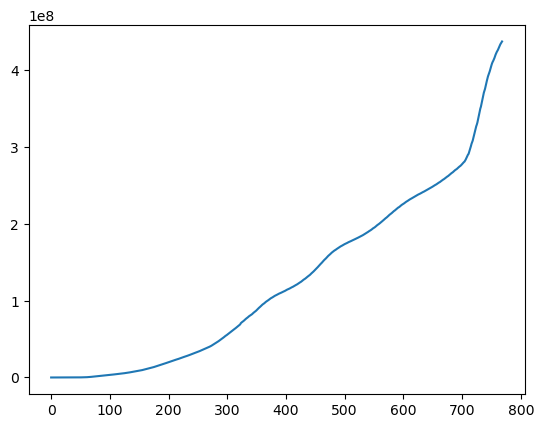

In [8]:
import matplotlib.pyplot as plt
plt.plot(covid_dias['dias_inicio'],covid_dias['casos_confirmados'])

In [9]:
#Preparamos X e y
X = covid_dias['dias_inicio'].to_frame()
y = covid_dias['casos_confirmados'].to_frame()


In [17]:
#Vamos a probar con un polinomio de grado 2:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
poly_features = PolynomialFeatures(degree=2,include_bias=False)
X_poly = poly_features.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size = 0.2, random_state = 0)



In [19]:
from sklearn.linear_model import LinearRegression
lm = LinearRegression()
lm.fit(X_train,y_train)


LinearRegression()

In [56]:
#Veamos que tal se ajusta a la curva:
y_pred = lm.predict(X_test)
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)


0.9976060945393153

In [57]:
#Probemos ahora con un grado superior:
poly_features = PolynomialFeatures(degree=6,include_bias=False)
X_poly = poly_features.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size = 0.2, random_state = 0)
lm = LinearRegression()
lm.fit(X_train,y_train)
y_pred = lm.predict(X_test)
r2_score(y_test,y_pred)


0.9976060945393153